In [1]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

# Load Data

In [2]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [3]:
# Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated=False)
baseline_period = analysis_utils.get_baseline_period(effect, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

In [4]:
# Compute the Mortality Impact relative to a Baseline Period for the Projected Effects
impact = analysis_utils.compute_impact(
    effect,
    socioeconomics,
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="net",
    rate=True,
    age_weight=True,
)

In [5]:
import seaborn as sns

<Axes: ylabel='sample'>

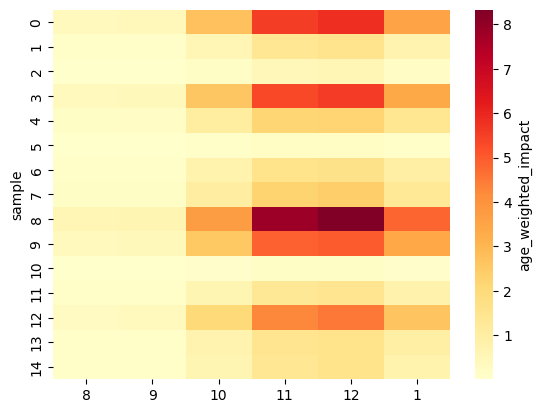

In [6]:
order = [8, 9, 10, 11, 12, 1]
da_ordered = impact.reindex(month=order)

da_ordered = da_ordered.isel(region=10000).var(dim="number")

df = da_ordered.transpose("sample", "month").to_pandas()
df.columns = order  # ensures column labels display in this order

sns.heatmap(df, cmap="YlOrRd", cbar_kws={"label": impact.name})

<Axes: ylabel='number'>

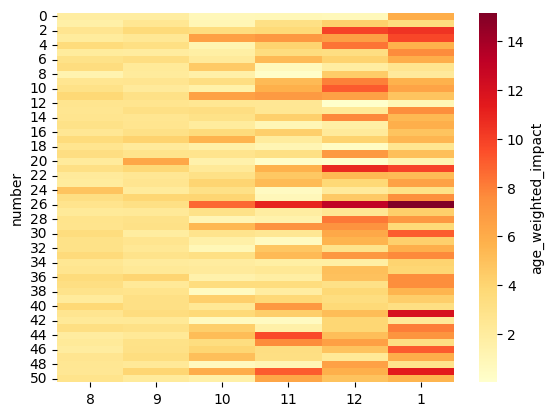

In [7]:
order = [8, 9, 10, 11, 12, 1]
da_ordered = impact.reindex(month=order)

da_ordered = da_ordered.isel(region=10000).var(dim="sample")

df = da_ordered.transpose("number", "month").to_pandas()
df.columns = order  # ensures column labels display in this order

sns.heatmap(df, cmap="YlOrRd", cbar_kws={"label": impact.name})

In [8]:
forecast_uncertainty = impact.var(dim="number")
# q = impact.quantile([0.1, 0.9], dim="number")
# forecast_uncertainty = q.sel(quantile=0.9) - q.sel(quantile=0.1)

econ_uncertainty = impact.var(dim="sample")

order = [8, 9, 10, 11, 12, 1]

df1 = forecast_uncertainty.to_dataframe(name="value").reset_index()
df1["source"] = "Forecast"
df2 = econ_uncertainty.to_dataframe(name="value").reset_index()
df2["source"] = "Economic"

df = pd.concat([df1, df2], ignore_index=True)
df["month"] = pd.Categorical(df["month"], categories=order, ordered=True)

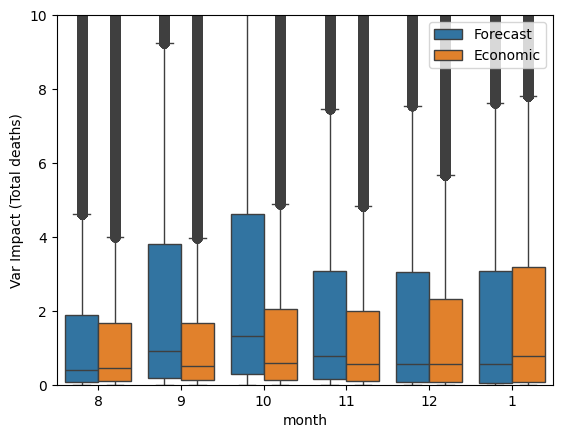

In [9]:
sns.boxplot(
    data=df, x="month", y="value", hue="source", hue_order=["Forecast", "Economic"]
)
plt.ylim(0, 10)
plt.ylabel("Var Impact (Total deaths)")
plt.legend(loc="upper right")

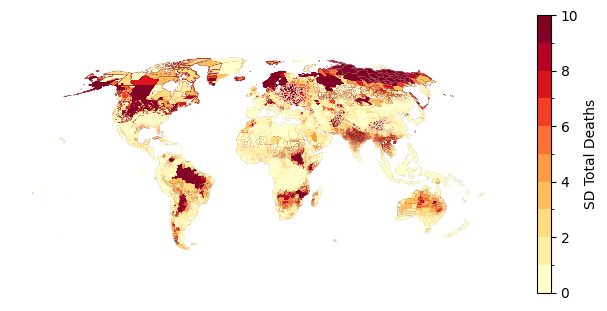

In [10]:
_polygons_fc_uncertainty = analysis_utils.xarray_to_gpd(
    forecast_uncertainty.sel(month=12), _polygons
)

ax = analysis_utils.plot_single(
    _polygons_fc_uncertainty,
    col="age_weighted_impact",
    cm="YlOrRd",
    n_colors=10,
    vmin=0,
    vmax=10,
    sup_title="",
    cbar_label="SD Total Deaths",
)

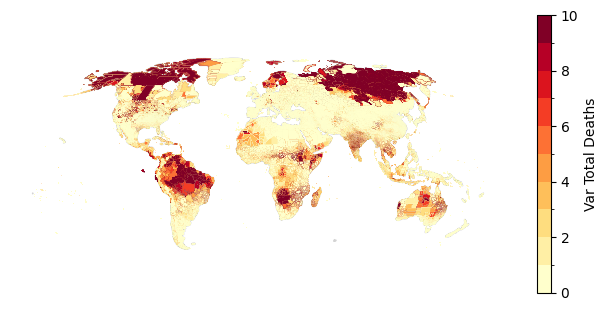

In [11]:
_polygons_econ_uncertainty = analysis_utils.xarray_to_gpd(
    econ_uncertainty.sel(month=12), _polygons
)

ax = analysis_utils.plot_single(
    _polygons_econ_uncertainty,
    col="age_weighted_impact",
    cm="YlOrRd",
    n_colors=10,
    vmin=0,
    vmax=10,
    sup_title="",
    cbar_label="Var Total Deaths",
)

In [12]:
ratio = forecast_uncertainty.mean(dim="sample") / econ_uncertainty.mean(dim="number")
_polygons_uncertainty_ratio = analysis_utils.xarray_to_gpd(ratio, _polygons)

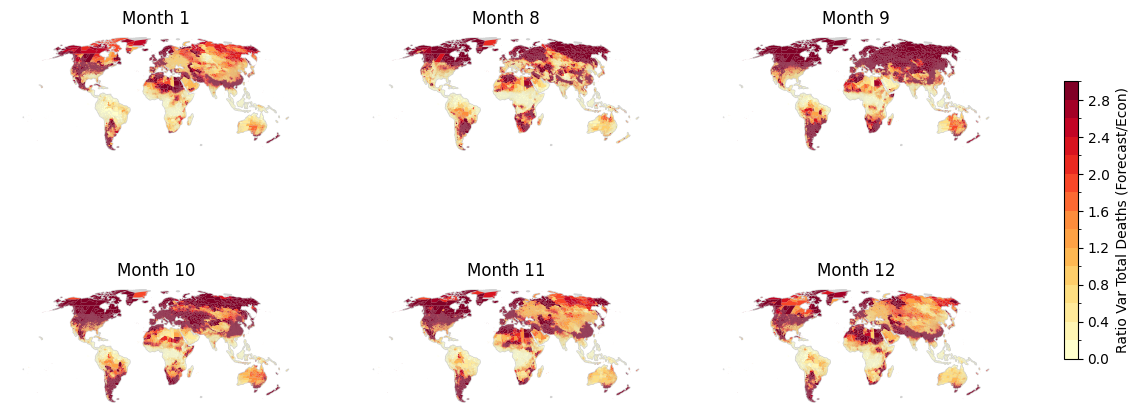

In [13]:
ax = analysis_utils.plot_monthly(
    _polygons_uncertainty_ratio,
    col="age_weighted_impact",
    cm="YlOrRd",
    n_colors=10,
    vmin=0,
    vmax=3,
    sup_title="",
    cbar_label="Ratio Var Total Deaths (Forecast/Econ)",
)

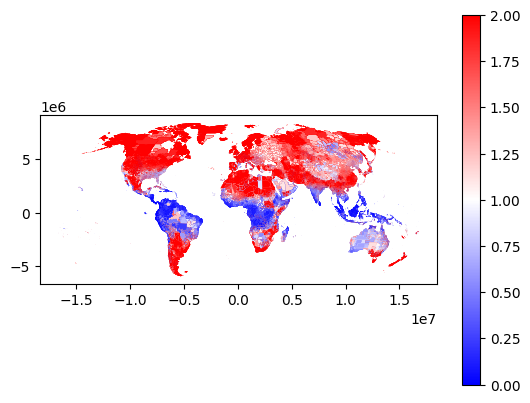

In [14]:
from matplotlib.colors import TwoSlopeNorm

norm = TwoSlopeNorm(vmin=0, vcenter=1, vmax=2)

ax = _polygons_uncertainty_ratio.plot(
    column="age_weighted_impact",
    cmap="bwr",
    norm=norm,
    legend=True,
)